## Electron Charge-to-Mass Ratio Analysis

This notebook uses experimental data of an electron beam to measure the charge-to-mass ratio of an electron using Python.

Linear fits of $2V$ vs $B^2 r^2$ gave a slope of $\frac{e}{m}$
using the relationship
$$
2V = \frac{e}{m} B^2 r^2
$$

In [157]:
# Imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import constants

## Load Data
The data was loaded from a csv file which contained the voltage, current, and radius values. Radius values are divided by 100 to convert to SI units.

In [ ]:
# Import csv file
data = pd.read_csv("~/Physics Projs/data/em_data.csv")

# Define & Calculate Relevant Parameters
voltage = data["V"]
current = data[" I"]
radius = data[" r"] / 100
B = (8 / np.sqrt(125)) * (constants.mu_0 * 72 / 0.33) * current

In [ ]:
# Compute x and y values
x = np.square(B) * np.square(radius)
y = 2 * voltage

## Adjust Data by Removing Outlier
To filter the data by removing the outlier which was caused by measurement error, the residuals were computed by linearly fitting the raw data.
The largest residual represents the greatest outlier and was taken out of the data set.

In [ ]:
# Outlier in data was due to a measurement error, obtain it's index & remove it
coeffs = np.polyfit(x, y, 1)
yfit = coeffs[0] * x + coeffs[1]
differences = y - yfit
outlier_ind = np.argmax(abs(differences))

# Use outlier index to clean parameters and axes values
voltage = np.delete(voltage, outlier_ind)
current = np.delete(current, outlier_ind)
radius = np.delete(radius, outlier_ind)
B = (8 / np.sqrt(125)) * (constants.mu_0 * 72 / 0.33) * current
x = np.square(B) * np.square(radius)
y = 2 * voltage

# Fit clean data to straight line for estimate of slope, e/m
x_line = np.linspace(min(x), max(x), 100)
e_m, intercept = np.polyfit(x, y, 1)
y_fit = e_m * x_line + intercept


## Uncertainty in Parameters
The uncertainties of the voltage $V$, current $I$, number of turns in the coil $N$, and radius of the coils $a$ were given in the experiment manual or determined by device reading.

The uncertainty in the radii of the beam $r$ was determined using the sample standard deviation from repeated trials. 

These uncertainties contributed to the propagation of error for the magnetic field $B$ and these were computed for error bars in the final plot.

In [ ]:
# Define and compute Uncertainties
del_volt = 0.1
del_current = 0.01
del_N = 0.1
del_a = 0.01
del_B = B * np.sqrt((del_current / current)**2 + (del_a / 0.33)**2 + (del_N / 72)**2)

# Different Uncertainties for r, use spread of data around mean method
r_trials = {
    "0.57": [0.573, 0.569, 0.570, 0.571],
    "0.52": [0.528, 0.519, 0.515, 0.524],
    "0.45": [0.446, 0.452, 0.441, 0.448],
    "0.39": [0.386, 0.395, 0.392, 0.388],
    "0.32": [0.317, 0.327, 0.321, 0.319],
}
r_mean = []
del_radius = []
for key in (r_trials): 
    values = np.array(r_trials[key])
    r_mean.append(np.mean(values))
    del_radius.append(np.std(values, ddof = 1))
del_radius = np.delete(np.array(del_radius), outlier_ind)

# Final uncertainties 
del_x = x * np.sqrt((2 * del_B / B)**2 + (2 * del_radius / radius )**2)
del_y = 2 * del_volt
 

## Final Fit & Plot
The data was visualized using a linear fit of the filtered data without the outlier.

The slope of the fit line gives $\frac{e}{m}$

Error bars are used to represent the propagated uncertainty in the experiment.



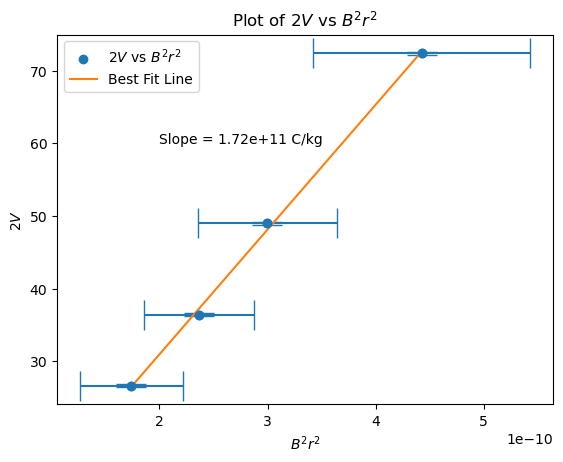

In [164]:
# Generate Plot of 2V vs B^2r^2
plt.scatter(x, y, label = (r"$2V$ vs $B^2r^2$"))
plt.title(r"Plot of $2V$ vs $B^2r^2$")
plt.errorbar(x, y, del_y, del_x, fmt = 'o', capsize = 11)
plt.plot(x_line, y_fit, label = "Best Fit Line")
plt.xlabel(r"$B^2r^2$")
plt.ylabel(r"$2V$")
plt.text(2e-10, 60, f"Slope = {e_m:.2e} C/kg")
plt.legend()
plt.savefig("/Users/benleon/Physics Projs/electron_charge_to_mass_ratio/plots/em_plot.png", dpi = 300)
plt.show()

## Results
The experimentally determined value of $\frac{e}{m}$ is compared to the accepted value and the percentage error is noted.

In [ ]:
# Accepted value of e/m
accepted = constants.e / constants.m_e
print("Percent error: ", round((abs(accepted - e_m) / accepted) * 100, 1))